In [65]:
import cmocean
import numpy as np 
import xarray as xr
import pandas as pd 
import seaborn as sns
import cartopy.crs as ccrs
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import HTML
from scipy.stats import linregress 
from nemo_cookbook import NEMODataTree 
from matplotlib.patches import Rectangle
from OceanDataStore import OceanDataCatalog 
from matplotlib.animation import FuncAnimation

In [66]:
catalog = OceanDataCatalog(catalog_name="noc-stac")

In [67]:
catalog.search(collection='noc-npd-era5', item_name='tn')



            * Item ID: noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/tn/M1m/MOVE_16N
              Title: M1m/MOVE_16N Icechunk repository
              Description: **Monthly mean ocean physics transect outputs defined at MOVE_16N.**

**OceanDataCatalog Access:**
`catalog.open_dataset(id='noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/tn/M1m/MOVE_16N')`
              Platform: tn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/tn/M1m/SAMBA_34_5S
              Title: M1m/SAMBA_34_5S Icechunk repository
              Description: **Monthly mean global ocean scalar outputs.**

**OceanDataCatalog Access:**
`catalog.open_dataset(id='noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/tn/M1m/SAMBA_34_5S')`
              Platform: tn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/r1i1c

In [68]:
ds1 = catalog.open_dataset(id=catalog.Items[11].id, start_datetime='1990-01', end_datetime='2024-12')

In [70]:
ds1['moc_total'] = ds1['moc_total'] * 1e-6

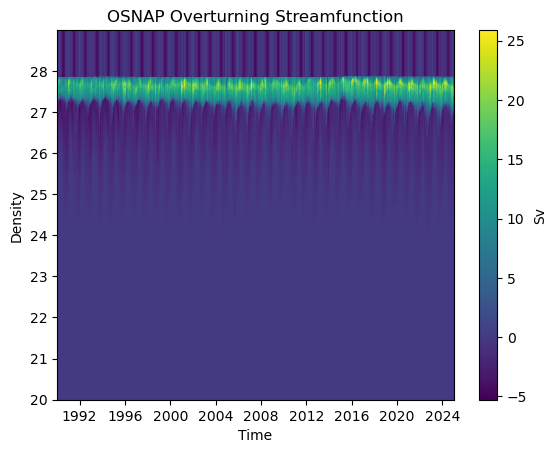

In [71]:
fig, ax = plt.subplots()

moc = ds1['moc_total']
pcm = ax.pcolormesh(moc['time_counter'], moc['sigma0_bins'], moc.T, shading='auto')
ax.set_xlabel('Time')
ax.set_ylabel('Density')
ax.set_title("OSNAP Overturning Streamfunction")
plt.colorbar(pcm, ax=ax, label='Sv')
# ax.set_xlim(np.datetime64('1990-01-01'), np.datetime64('2024-12-31'))
# ax.set_ylim(26,28)

In [72]:
# Summer only

moc_july = ds1['moc_total'].where(ds1['time_counter'].dt.month == 7, drop = True)


(26.0, 28.0)

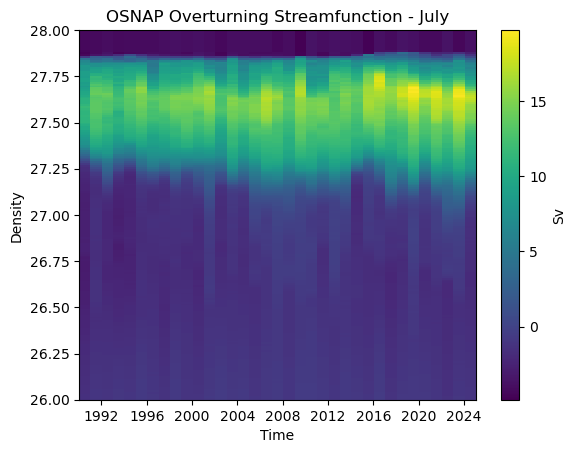

In [73]:
fig, ax = plt.subplots()

pcm = ax.pcolormesh(moc_july['time_counter'], moc_july['sigma0_bins'], moc_july.T, shading='auto')
ax.set_xlabel('Time')
ax.set_ylabel('Density')
ax.set_title("OSNAP Overturning Streamfunction - July")
plt.colorbar(pcm, ax=ax, label='Sv')
ax.set_ylim(26,28)

In [74]:
max_sf = moc.max(dim = 'sigma0_bins')

Text(0, 0.5, 'Maximum Overturning Streamfunction (Sv)')

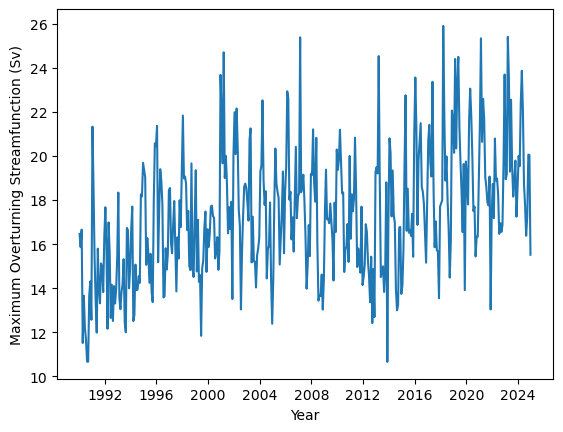

In [75]:
plt.plot(max_sf['time_counter'], max_sf)
plt.xlabel('Year')
plt.ylabel('Maximum Overturning Streamfunction (Sv)')

Text(0, 0.5, 'Maximum Overturning Streamfunction (Sv) - Annual Mean')

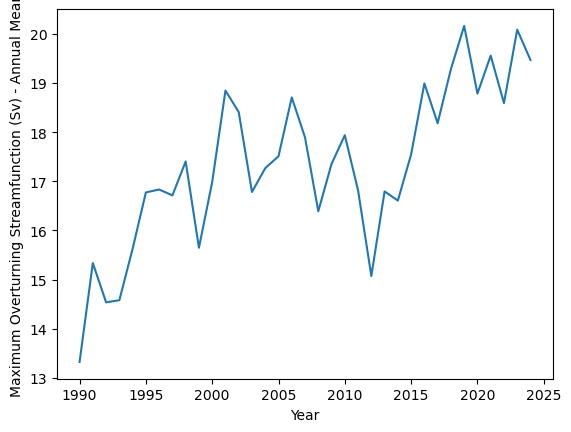

In [76]:
annual_mean = max_sf.groupby('time_counter.year').mean()
plt.plot(annual_mean['year'], annual_mean)
plt.xlabel('Year')
plt.ylabel('Maximum Overturning Streamfunction (Sv) - Annual Mean')

In [77]:
observations = xr.open_dataset('OSNAP_Streamfunction_201408_202207_2025.nc')['T_ALL'] 
observations

<xarray.DataArray 'T_ALL' (LEVEL: 481, TIME: 96)> Size: 369kB
[46176 values with dtype=float64]
Coordinates:
  * LEVEL    (LEVEL) float64 4kB 23.3 23.31 23.32 23.33 ... 28.08 28.09 28.1
  * TIME     (TIME) datetime64[ns] 768B 2014-08-01T12:00:00 ... 2022-07-01T12...
Attributes:
    Coordinates:       TIME LEVEL
    long_name:         Overturning streamfunction across the full OSNAP array
    units:             Sv
    QC_indicatoris:    good data
    processing_level:  data manually reviewed
    comment:           Streamfunction in sigma_theta coordinates

In [78]:
annual_observations = observations.groupby('TIME.year').mean()


In [79]:
OSNAP_annual_maxsf = annual_observations.max(dim = 'LEVEL')
OSNAP_annual_maxsf = OSNAP_annual_maxsf.sel(year = slice(2015, 2021))

In [80]:
OSNAP_annual_maxsf

<xarray.DataArray 'T_ALL' (year: 7)> Size: 56B
array([16.35161872, 15.28456011, 14.64134112, 15.73160838, 14.741874  ,
       16.53701732, 15.6955557 ])
Coordinates:
  * year     (year) int64 56B 2015 2016 2017 2018 2019 2020 2021
Attributes:
    Coordinates:       TIME LEVEL
    long_name:         Overturning streamfunction across the full OSNAP array
    units:             Sv
    QC_indicatoris:    good data
    processing_level:  data manually reviewed
    comment:           Streamfunction in sigma_theta coordinates

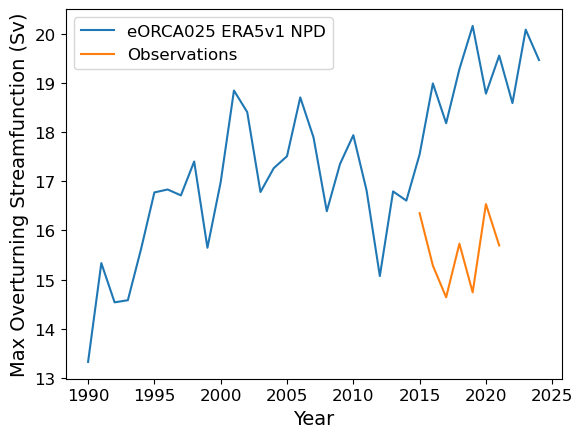

In [81]:
plt.plot(annual_mean['year'], annual_mean, label = 'eORCA025 ERA5v1 NPD')
plt.plot(OSNAP_annual_maxsf['year'], OSNAP_annual_maxsf, label = 'Observations')
plt.xlabel('Year', fontsize = 14)
plt.ylabel('Max Overturning Streamfunction (Sv)', fontsize = 14)
plt.legend(loc = 'best', fontsize = 12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('OSNAP.png')
plt.show()
